# Otimização de Despacho de Armazenamento em Bateria para Arbitragem de Energia e Corte de Pico

## Resumo Executivo

Um site comercial conectado à rede opera uma bateria de íon-lítio de 2 MW / 8 MWh ao lado de uma carga elétrica medida. O site é faturado de duas maneiras: um **preço de energia** horário do dia seguinte ($/MWh) e um **encargo de demanda** mensal sobre seu maior intervalo de importação da rede ($/MW). O gestor do ativo deve decidir, hora a hora, quando carregar a bateria (comprando energia barata e elevando a retirada da rede) e quando descarregá-la (compensando energia cara e reduzindo a retirada da rede). Dois fluxos de valor competem: **arbitragem de energia** (comprar barato durante a noite, descarregar no pico da tarde) e **corte de pico** (limitar o máximo faturado da rede). Carregar não é gratuito — a eficiência de ida e volta significa que cerca de 10% da energia armazenada é perdida — portanto o cronograma é uma otimização genuína, não uma heurística.

Este notebook constrói a decisão de ponta a ponta. Ele primeiro sintetiza uma curva realista de preços do dia seguinte de 24 horas (com picos de manhã e de tarde mais um vale noturno) e um perfil de carga do site correlacionado, depois traça o perfil de ambos com o **PROC MEANS** e uma faixa robusta de percentis de preço 2.5/97.5 do **PROC UNIVARIATE**. O núcleo é um programa linear no **PROC OPTMODEL**: variáveis de decisão para carga, descarga e estado de carga horários, mais uma variável de pico faturado, sujeitas a um balanço cumulativo de estado de carga (com eficiência separada de carga/descarga), limites de potência e de capacidade, e uma restrição de definição de pico. O objetivo maximiza a margem de arbitragem líquida do encargo de demanda. O **PROC SQL** então quantifica o custo de linha de base versus otimizado, e três painéis do **PROC SGPLOT** visualizam o cronograma de carga/descarga contra o preço, a trajetória do estado de carga e o perfil achatado de importação da rede.

**Resultado no dia sintético:** o otimizador enche a bateria durante as horas noturnas mais baratas, descarrega tanto no pico de preço da manhã quanto no da tarde, recarrega durante o vale de preço do meio-dia e — crucialmente — segura sua potência de carga para nunca criar um novo pico de rede. O custo diário de energia cai de **\$2,903.78 para \$2,528.43** — **\$375.34 (12.9%) de economia de arbitragem** — enquanto o máximo faturado da rede cai de **3.59 MW para 3.43 MW** (cerca de **0.16 MW**), valendo mais **\$18.98** ao encargo de demanda de participação diária assumido. O mesmo modelo escala para horizontes mais longos, múltiplos cenários de preço ou ciclagem consciente da degradação simplesmente estendendo o conjunto de índices e as restrições.

## Fontes de Dados

Todos os dados são **sintéticos**, gerados inline na primeira célula de código com `CALL STREAMINIT(20260605)` para reprodutibilidade. Sem arquivos externos ou acesso à rede. Um conjunto de dados, `price_load`, com 24 linhas horárias representando um único dia de operação.

| Variável | Tipo | Unidades | Descrição |
|----------|------|-------|-------------|
| `hour` | num | 0–23 | Hora do dia de operação (índice do horizonte) |
| `price` | num | $/MWh | Preço de energia do dia seguinte: vale noturno, picos de manhã + tarde, com ruído gaussiano (com piso em $5) |
| `load` | num | MW | Demanda elétrica do site, correlacionada com a atividade diária (com piso em 0.3 MW) |
| `day_type` | char | — | Sinalização de janela tarifária: `Pico` (horas 17–21) vs `ForaPico`, usada no resumo do spread de preço pico/fora de pico |

Os parâmetros da bateria são constantes fixas do modelo dentro do PROC OPTMODEL: 8 MWh de capacidade utilizável, 2 MW de potência máxima de carga/descarga, 0.95 de eficiência de carga e 0.95 de descarga (~90% de ida e volta), estado de carga inicial de 0 MWh, e um encargo de demanda de \$120/MW aplicado ao pico de rede faturado do dia (a parcela diária amortizada de um encargo de demanda mensal).

# Otimização de Despacho de Armazenamento em Bateria
## Arbitragem de energia e corte de pico para um site conectado à rede

Um site comercial opera uma **bateria de 2 MW / 8 MWh** atrás de seu medidor. Sua conta de eletricidade tem duas partes: um **preço de energia** horário ($/MWh) e um **encargo de demanda** mensal sobre o maior intervalo de importação da rede ($/MW). O operador quer um cronograma horário de carga/descarga que capture dois fluxos de valor ao mesmo tempo:

- **Arbitragem** — armazenar energia noturna barata, liberá-la durante as horas de pico caras.
- **Corte de pico** — descarregar durante o pico de demanda para reduzir o máximo faturado da rede.

Como a eficiência de ida e volta perde ~10% da energia armazenada, o trade-off não é trivial e justifica uma otimização de verdade. Formulamos isso como um programa linear no **PROC OPTMODEL**, depois quantificamos e visualizamos o resultado.

> Todos os dados abaixo são sintéticos e gerados inline — o notebook é totalmente autocontido e roda em poucos segundos.

## 1. Gerar um perfil sintético de preço e carga do dia seguinte

Construímos um dia de operação (24 linhas horárias). A curva de preços tem um vale noturno e picos de manhã + tarde; a carga do site é correlacionada com a atividade diária. Uma semente fixa mantém a execução reprodutível. Também marcamos a janela de pico de horário de uso estatutária para que possamos resumir o spread pico/fora de pico mais tarde.

In [1]:
DADOS price_load;
    CHAMAR streaminit(20260605);
    COMPRIMENTO day_type $12;
    RÓTULO hour="Hora do dia"
          price="Preço ($/MWh)"
          LOAD="Carga do site (MW)"
          day_type="Janela tarifária";
    FAZER hour = 0 ATÉ 23;
        /* Preço diurno de energia ($/MWh): picos de manhã + tarde */
        BASE = 38
             + 26 * EXP(-((hour - 8)**2) / 6)
             + 40 * EXP(-((hour - 19)**2) / 5)
             - 14 * EXP(-((hour - 3)**2) / 8);
        price = round(BASE + rand('normal', 0, 4), 0.01);
        SE price < 5 ENTÃO price = 5;

        /* Carga do site (MW): vale noturno, rampa da tarde */
        LOAD = round(2.0
             + 1.6 * EXP(-((hour - 19)**2) / 7)
             + 0.7 * EXP(-((hour - 9)**2) / 10)
             + rand('normal', 0, 0.10), 0.01);
        SE LOAD < 0.3 ENTÃO LOAD = 0.3;

        SE hour >= 17 E_LÓGICO hour <= 21 ENTÃO day_type = 'Pico';
        SENÃO day_type = 'ForaPico';
        SAÍDA;
    FIM;
    REMOVER BASE;
EXECUTAR;


NOTE: DATA price_load


NOTE: Wrote price_load (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Traçar o perfil das distribuições de preço e carga

Antes de otimizar, fazemos uma verificação de sanidade das entradas. O spread entre as horas mais baratas e mais caras é o que a arbitragem monetiza, e a carga máxima ancora a oportunidade de corte de pico.

In [2]:
PROCEDIMENTO MÉDIAS DADOS=price_load n mean std MIN MAX maxdec=2;
    VARIÁVEL price LOAD;
EXECUTAR;

                                                  The MEANS Procedure

 Variable  Label                     N        Mean     Std Dev     Minimum     Maximum
 -------------------------------------------------------------------------------------
 price     Preço ($/MWh)            24       46.29       15.81       18.57       79.27
 LOAD      Carga do site (MW)       24        2.47        0.48        1.71        3.59
 -------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Spread de preço pico vs fora de pico

Agrupar pela sinalização de horário de uso mostra quanto mais ricas são as horas de pico em relação à linha de base de fora de pico — o sinal estrutural que a bateria explora.

In [3]:
PROCEDIMENTO MÉDIAS DADOS=price_load mean MIN MAX maxdec=2;
    CLASSE day_type;
    VARIÁVEL price;
EXECUTAR;

                                                  The MEANS Procedure

                                       Analysis Variable : price Preço ($/MWh)

                                                    N
                             Janela tarifária     Obs       Mean      Minimum      Maximum
                             -------------------------------------------------------------
                             ForaPico              19      40.46        18.57        54.89
                             Pico                   5      68.45        54.88        79.27
                             -------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Faixa robusta de preço (percentis 2.5 / 97.5)

Caracterizamos as caudas de preço com uma faixa de percentis 2.5 / 97.5. O **PROC UNIVARIATE** com `PCTLPTS=` calcula percentis arbitrários de forma limpa, o que é a ferramenta correta para percentis fracionários.

In [4]:
PROCEDIMENTO UNIVARIATE DADOS=price_load NOPRINT;
    VARIÁVEL price;
    SAÍDA out=price_band pctlpts=2.5 97.5 pctlpre=p_;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=price_band noobs RÓTULO;
    RÓTULO p_2_5="Percentil 2,5 do preço ($/MWh)"
          p_97_5="Percentil 97,5 do preço ($/MWh)";
EXECUTAR;


 Percentil 2,5 do preço ($/MWh)   Percentil 97,5 do preço ($/MWh)
-------------------------------  --------------------------------
                          18.57                             79.27




NOTE: PROC UNIVARIATE
NOTE: Output dataset price_band has 1 observations and 2 variables.
NOTE: PROC PRINT data=price_band

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 5. A otimização de despacho (programa linear)

Lemos o preço e a carga horários no PROC OPTMODEL e declaramos:

- `chg[h]`, `dis[h]` — potência de carga / descarga horária (MW), limitada pela classificação de 2 MW do inversor.
- `soc[h]` — estado de carga (MWh), limitado pela capacidade utilizável de 8 MWh.
- `peak` — o máximo faturado da rede (MW).

**Restrições.** `soc_balance` acumula a energia líquida ao longo de cada hora com eficiência separada de carga/descarga (uma forma de soma corrente da recorrência horária). `peak_def` força `peak` a dominar a importação líquida da rede de cada hora, de modo que minimizá-lo reduz o encargo de demanda.

**Objetivo.** Maximizar a margem de arbitragem — `price × (discharge − charge)` somada ao longo do dia — menos o encargo de demanda sobre o pico faturado. Resolvemos como um LP contínuo.

In [5]:
PROCEDIMENTO optmodel;
    DEFINIR HOURS;
    num price{HOURS};
    num LOAD{HOURS};

    READ DADOS price_load INTO HOURS=[hour]
        price=price col=price
        LOAD=LOAD col=LOAD;

    /* Bateria: 8 MWh utilizáveis, 2 MW de potência, ~90% de ida e volta */
    num capacity   = 8.0;
    num p_max      = 2.0;
    num eta_chg    = 0.95;
    num eta_dis    = 0.95;
    num soc0       = 0.0;
    num dt         = 1.0;
    /* Encargo de demanda aplicado ao pico de rede faturado do dia ($/MW).
       Encargos de demanda comerciais são mensais; 120 é o valor marginal de
       reduzir o máximo de rede de hoje uma vez que o encargo mensal é
       amortizado ao dia. É grande o suficiente para que o otimizador segure
       a potência de carga em vez de criar um pico novo e mais alto. */
    num demand_chg = 120;

    /* Variáveis de decisão (MW carga / descarga, MWh estado de carga) */
    VARIÁVEL chg{HOURS}  >= 0 <= p_max;
    VARIÁVEL dis{HOURS}  >= 0 <= p_max;
    VARIÁVEL soc{HOURS}  >= 0 <= capacity;
    VARIÁVEL peak        >= 0;   /* pico de rede faturado (MW) para o encargo de demanda */

    /* Importação líquida da rede após ação da bateria (MW) */
    impvar grid_mw{h IN HOURS} = LOAD[h] + chg[h] - dis[h];

    /* Estado de carga cumulativo: energia que entra menos energia que sai até
       a hora h, com eficiência de carga/descarga aplicada. Equivalente a uma
       recorrência horária mas expressa como soma corrente sobre horas anteriores. */
    con soc_balance{h IN HOURS}:
        soc[h] = soc0
                 + sum{k IN HOURS: k <= h}
                     (eta_chg * chg[k] - dis[k] / eta_dis) * dt;

    /* Corte de pico: o pico faturado é a máxima importação da rede no dia */
    con peak_def{h IN HOURS}: peak >= grid_mw[h];

    /* Maximizar a margem de arbitragem de energia líquida do encargo de demanda */
    MAX net_value =
        sum{h IN HOURS} price[h] * (dis[h] - chg[h]) * dt
        - demand_chg * peak;

    solve WITH lp;

    CRIAR DADOS dispatch DE_TABELA [hour=HOURS]
        price=price[hour]
        LOAD=LOAD[hour]
        charge_mw=chg[hour]
        discharge_mw=dis[hour]
        soc_mwh=soc[hour]
        grid_mw=grid_mw[hour];
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Maximization
  Objective Function            NET_VALUE
  Objective Type                Linear

  Number of Variables           73
  Bounded Above                 0
  Bounded Below                 1
  Bounded Below and Above       72
  Free                          0
  Fixed                         0

  Number of Constraints         48

                          Solution Summary
  Solver                        LP
  Objective Function            NET_VALUE
  Solution Status               Optimal
  Objective Value               -36.4771665526




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 6. O cronograma horário ótimo

A tabela resolvida mostra a carga distribuída pelas horas noturnas e de meio-dia baratas — moderada para cerca de 1.0–1.7 MW para que nunca estabeleça um novo pico de rede — a descarga concentrada nos picos de preço da manhã e da tarde, e o estado de carga traçando um ciclo sensato de enchimento e liberação dentro do limite de 8 MWh. A coluna `grid_mw` mantém um teto plano de ~3.43 MW ao longo de cada hora de carga, a assinatura da restrição de pico ativa.

In [6]:
PROCEDIMENTO IMPRIMIR DADOS=dispatch noobs RÓTULO;
    RÓTULO hour="Hora do dia"
          price="Preço ($/MWh)"
          LOAD="Carga do site (MW)"
          charge_mw="Carga da bateria (MW)"
          discharge_mw="Descarga da bateria (MW)"
          soc_mwh="Estado de carga (MWh)"
          grid_mw="Importação da rede (MW)";
    VARIÁVEL hour price LOAD charge_mw discharge_mw soc_mwh grid_mw;
EXECUTAR;


Hora do dia   Preço ($/MWh)  Carga do site (MW)  Carga da bateria (MW)  Descarga da bateria (MW)  Estado de carga (MWh)    Importação da rede (MW)
-----------  --------------  ------------------  ---------------------  ------------------------  ---------------------  -------------------------
          0           29.73                1.99              1.4418421                         0                1.36975                  3.4318421
          1           28.03                2.16              1.2718421                         0                  2.578                  3.4318421
          2           21.87                   2              1.4318421                         0                3.93825                  3.4318421
          3           18.57                1.71              1.7218421                         0                  5.574                  3.4318421
          4           27.62                2.13              1.3018421                         0                6.810


NOTE: PROC PRINT data=dispatch

NOTE: PROC PRINT completed: 24 observations printed, 7 variables


## 7. KPIs de destaque: linha de base vs otimizado

Comparamos a linha de base de não fazer nada (pagar o preço pela carga bruta a cada hora) contra a posição de rede otimizada, e reportamos a economia de arbitragem, a redução no pico faturado e o valor em dólares dessa redução ao encargo de demanda — as duas alavancas que impulsionam o caso de negócio.

In [7]:
PROCEDIMENTO SQL;
    CRIAR TABELA kpi AS
    SELECIONAR
        sum(price * LOAD)                        AS base_energy_cost,
        sum(price * grid_mw)                     AS opt_energy_cost,
        sum(price * LOAD) - sum(price * grid_mw) AS arbitrage_savings,
        MAX(LOAD)                                AS base_peak_mw,
        MAX(grid_mw)                             AS opt_peak_mw,
        MAX(LOAD) - MAX(grid_mw)                 AS peak_reduction_mw,
        120 * (MAX(LOAD) - MAX(grid_mw))         AS demand_charge_savings
    DE_TABELA dispatch;
QUIT;

PROCEDIMENTO IMPRIMIR DADOS=kpi noobs RÓTULO;
    RÓTULO base_energy_cost="Custo de energia (linha de base) ($)"
          opt_energy_cost="Custo de energia (otimizado) ($)"
          arbitrage_savings="Economia de arbitragem ($)"
          base_peak_mw="Pico linha de base (MW)"
          opt_peak_mw="Pico otimizado (MW)"
          peak_reduction_mw="Redução de pico (MW)"
          demand_charge_savings="Economia no encargo de demanda ($)";
EXECUTAR;

Custo de energia (linha de base) ($)  Custo de energia (otimizado) ($)  Economia de arbitragem ($)  Pico linha de base (MW)  Pico otimizado (MW)    Redução de pico (MW)  Economia no encargo de demanda ($)
------------------------------------  --------------------------------  --------------------------  -----------------------  -------------------  ----------------------  ----------------------------------
                           2903.7774                   2528.4335145526              375.3438854474                     3.59            3.4318421               0.1581579                           18.978948




NOTE: PROC SQL 

NOTE: Table kpi created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=kpi

NOTE: PROC PRINT completed: 1 observations printed, 7 variables


## 8. Cronograma de carga / descarga contra o preço

Carga (agulhas azuis) e descarga (linha vermelha com marcadores) compartilham o eixo de megawatts à esquerda; o preço do dia seguinte (verde tracejado) é lido à direita. A carga se concentra nas horas noturnas e de meio-dia baratas, enquanto a descarga dispara nos picos de preço da manhã e da tarde — o visual confirma que o otimizador está comprando barato e vendendo caro.


NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


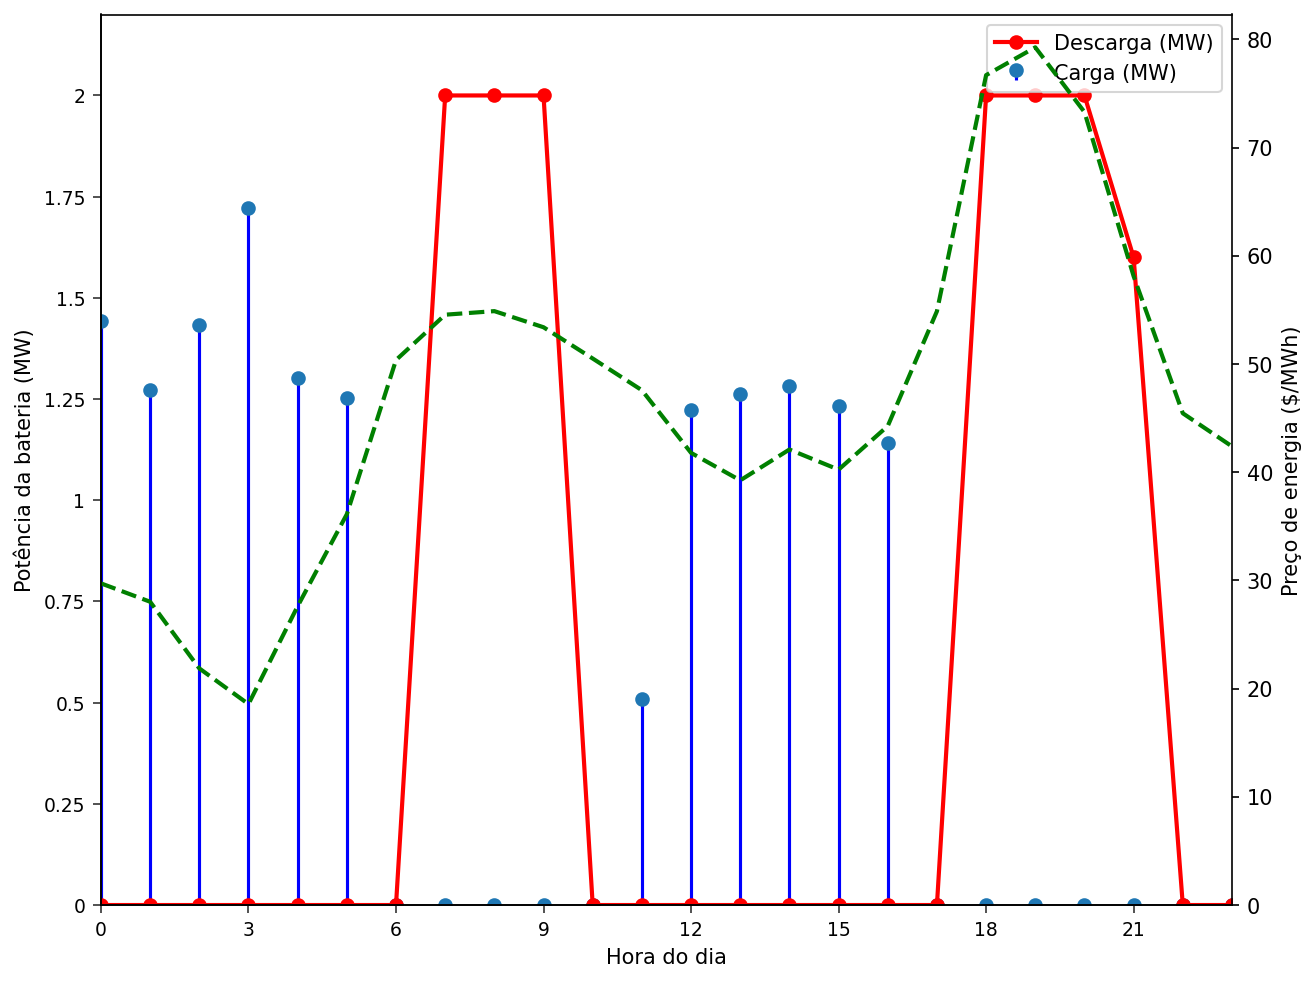

In [8]:
PROCEDIMENTO SGPLOT DADOS=dispatch;
    needle x=hour y=charge_mw / LINEATTRS=(color=blue thickness=3)
        legendlabel="Carga (MW)";
    SERIES x=hour y=discharge_mw / LINEATTRS=(color=red thickness=2)
        MARKERS legendlabel="Descarga (MW)";
    SERIES x=hour y=price / y2axis LINEATTRS=(color=green pattern=dash thickness=2)
        legendlabel="Preço ($/MWh)";
    XAXIS RÓTULO="Hora do dia" VALUES=(0 ATÉ 23 POR 3);
    YAXIS RÓTULO="Potência da bateria (MW)" MIN=0 MAX=2.2;
    y2axis RÓTULO="Preço de energia ($/MWh)" MIN=0;
EXECUTAR;

## 9. Trajetória do estado de carga

A energia armazenada sobe à medida que a bateria enche durante a noite, é reduzida ao longo de cada janela de descarga e nunca ultrapassa o teto de capacidade utilizável de 8 MWh (referência pontilhada).


NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


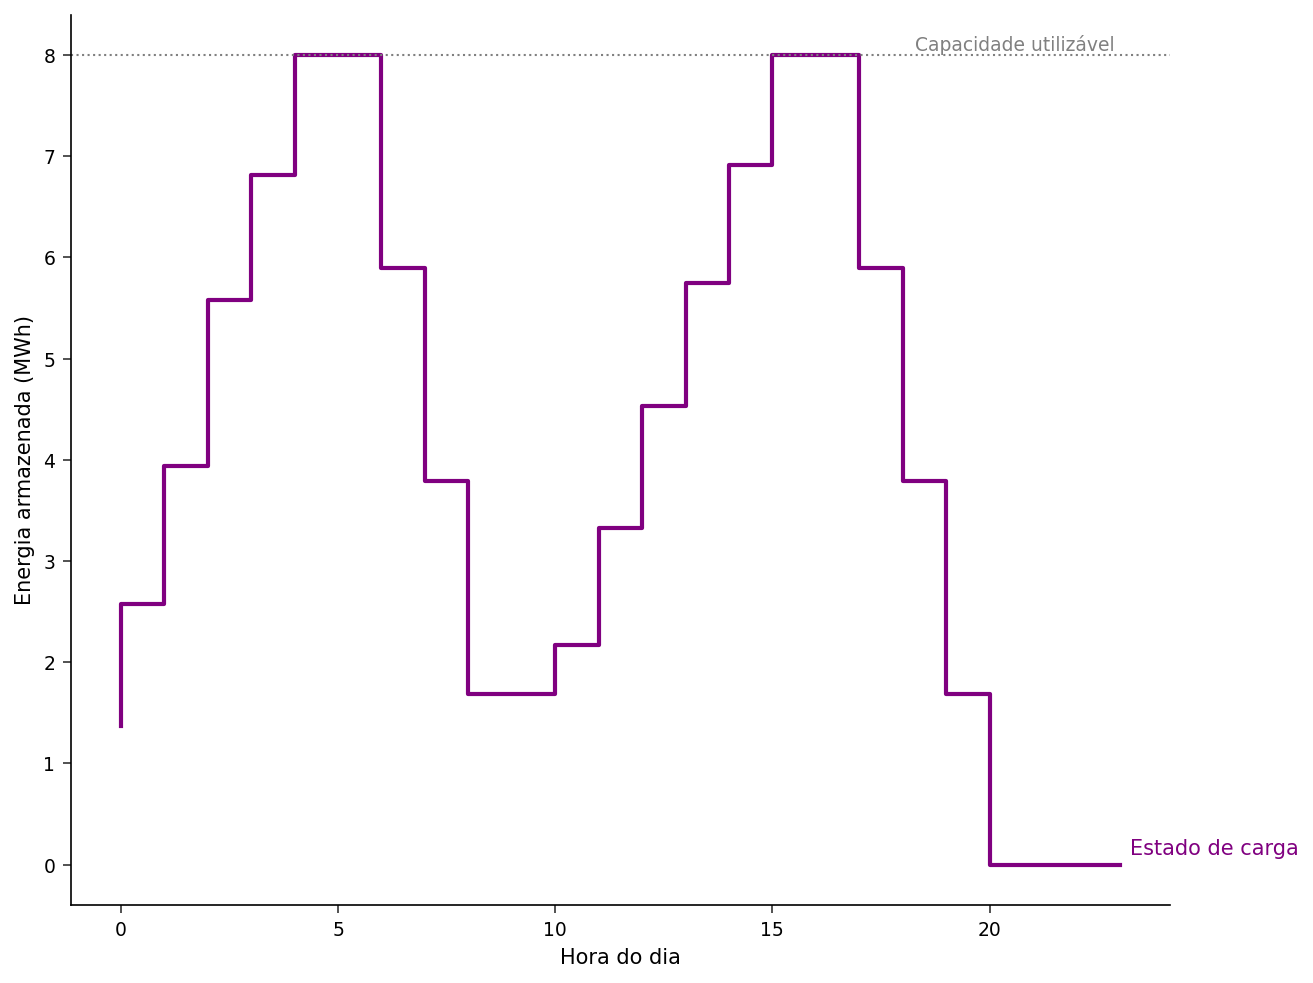

In [9]:
PROCEDIMENTO SGPLOT DADOS=dispatch;
    STEP x=hour y=soc_mwh / LINEATTRS=(color=purple thickness=2)
        curvelabel="Estado de carga";
    REFLINE 8 / AXIS=y LINEATTRS=(color=grey pattern=dot)
        RÓTULO="Capacidade utilizável";
    XAXIS RÓTULO="Hora do dia";
    YAXIS RÓTULO="Energia armazenada (MWh)";
EXECUTAR;

## 10. Importação da rede: antes vs depois do despacho

A linha laranja (importação da rede com a bateria) cai bem abaixo da carga de linha de base tracejada ao longo da rampa da tarde (horas 18–21) — o efeito de corte de pico que reduz o encargo de demanda. Durante as janelas de carga noturnas e de meio-dia ela sobe, mas o otimizador a limita a um teto plano de ~3.43 MW que permanece *abaixo* do pico de carga original de 3.59 MW, de modo que a carga compra energia barata sem estabelecer um novo máximo faturado.


NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


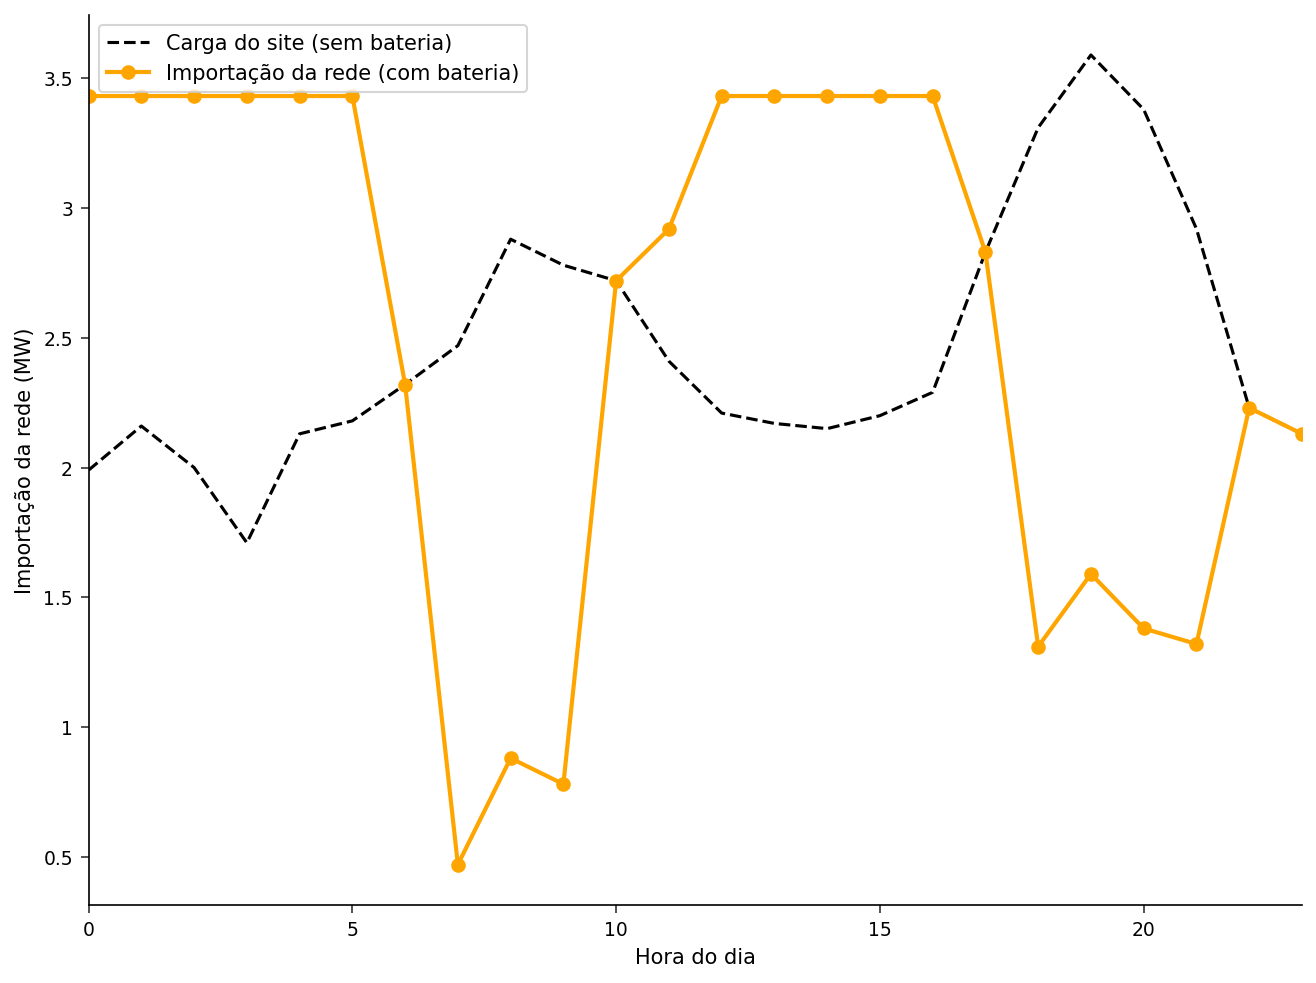

In [10]:
PROCEDIMENTO SGPLOT DADOS=dispatch;
    SERIES x=hour y=LOAD / LINEATTRS=(color=black pattern=dash)
        legendlabel="Carga do site (sem bateria)";
    SERIES x=hour y=grid_mw / LINEATTRS=(color=orange thickness=2)
        MARKERS legendlabel="Importação da rede (com bateria)";
    XAXIS RÓTULO="Hora do dia";
    YAXIS RÓTULO="Importação da rede (MW)";
EXECUTAR;

## Interpretação e próximos passos

**O que o modelo decidiu.** Com a eficiência de ida e volta taxando cada ciclo, o otimizador ainda encontrou valor claro: encheu a bateria durante as horas noturnas mais baratas, descarregou no pico de preço da manhã (horas 7–9), recarregou durante o vale de preço do meio-dia (horas 11–16) e descarregou novamente no pico mais rico da tarde (horas 18–21). Notavelmente, carregou a apenas 1.0–1.7 MW em vez da classificação plena de 2 MW durante o enchimento noturno — segurando a potência para que a retirada adicional da rede nunca empurrasse a importação acima do pico de carga do dia. O estado de carga respeitou tanto a capacidade de 8 MWh quanto o limite de potência de 2 MW o tempo todo.

**O caso de negócio.** O custo diário de energia caiu de **\$2,903.78 para \$2,528.43** — **\$375.34 (12.9%)** de economia de arbitragem — e o máximo faturado da rede caiu de **3.59 MW para 3.43 MW** (cerca de **0.16 MW**), cortando mais **\$18.98** da linha do encargo de demanda. Anualizado ao longo dos dias de operação, mais a redução recorrente do encargo de demanda, este é o tipo de margem que sustenta um investimento em armazenamento.

**Por que um LP é a ferramenta certa.** Heurísticas ("carregar abaixo do preço mediano, descarregar acima") ignoram as perdas de eficiência, o acoplamento de capacidade entre as horas e o fato de que o encargo de demanda depende de um único intervalo — elas carregariam à potência plena durante a noite e *elevariam* o pico faturado, destruindo o valor do corte de pico. O PROC OPTMODEL captura tudo isso em um único modelo declarativo e retorna o cronograma comprovadamente ótimo, que aqui deliberadamente modera a taxa de carga para proteger o pico.

**Estendendo o modelo.**

- **Horizontes mais longos / multidias** — ampliar o conjunto de índices `HOURS`; adicionar limites de ciclagem entre dias.
- **Incerteza de preço** — resolver o LP em múltiplos cenários de preço e tirar a média da decisão da primeira hora (uma política estocástica contínua).
- **Degradação da bateria** — adicionar um termo de penalidade de throughput ou uma restrição sobre ciclos cumulativos para equilibrar arbitragem contra a vida útil do ativo.
- **Resposta em frequência / mercados de capacidade** — introduzir restrições de folga reservada para que a bateria possa empilhar receita de serviços auxiliares por cima da arbitragem.

Todas essas são edições incrementais no mesmo bloco OPTMODEL — a estrutura estabelecida aqui se mantém inalterada.